## DECISION TREE

#### Objective:

The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.


#### Tasks:

##### 1. Data Preparation:
    
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).


In [1]:
# Import required libraries
import pandas as pd
import numpy as np

# File path (use raw string to avoid errors with backslashes)
file_path = r"C:\Users\Rakshitha\Downloads\heart_disease.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Display first 5 rows
print("First 5 rows of dataset:")
print(df.head())

# Check dataset info
print("\nDataset Info:")
print(df.info())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows of dataset:
    age   sex               cp  trestbps   chol    fbs         restecg  \
0  63.0  Male   typical angina     145.0  233.0   True  lv hypertrophy   
1  41.0  Male  atypical angina     135.0  203.0  False          normal   
2  57.0  Male     asymptomatic     140.0  192.0  False          normal   
3  52.0  Male   typical angina     118.0  186.0  False  lv hypertrophy   
4  57.0  Male     asymptomatic     110.0  201.0  False          normal   

   thalch  exang  oldpeak        slope          thal  num  
0   150.0  FALSE      2.3  downsloping  fixed defect  0.0  
1   132.0  FALSE      0.0         flat  fixed defect  0.0  
2   148.0  FALSE      0.4         flat  fixed defect  0.0  
3   190.0  FALSE      0.0         flat  fixed defect  0.0  
4   126.0   TRUE      1.5         flat  fixed defect  0.0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------

##### 2. Exploratory Data Analysis (EDA):

Perform exploratory data analysis to understand the structure of the dataset.
    
Check for missing values, outliers, and inconsistencies in the data.
    
Visualize the distribution of features, including histograms, box plots, and correlation matrices.


Shape of dataset: (999, 13)

Column Names:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

Data Types:
age         float64
sex          object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
thal         object
num         float64
dtype: object

First 5 Rows:
    age   sex               cp  trestbps   chol    fbs         restecg  \
0  63.0  Male   typical angina     145.0  233.0   True  lv hypertrophy   
1  41.0  Male  atypical angina     135.0  203.0  False          normal   
2  57.0  Male     asymptomatic     140.0  192.0  False          normal   
3  52.0  Male   typical angina     118.0  186.0  False  lv hypertrophy   
4  57.0  Male     asymptomatic     110.0  201.0  False          normal   

   thalch  exang  oldpeak        slope          thal  num  
0

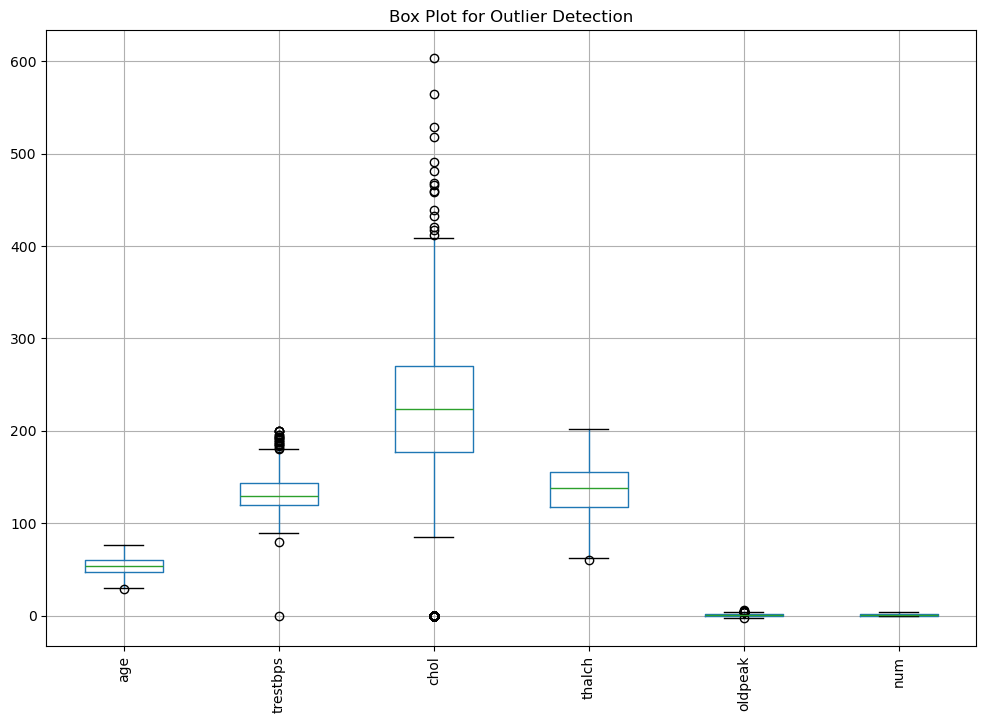

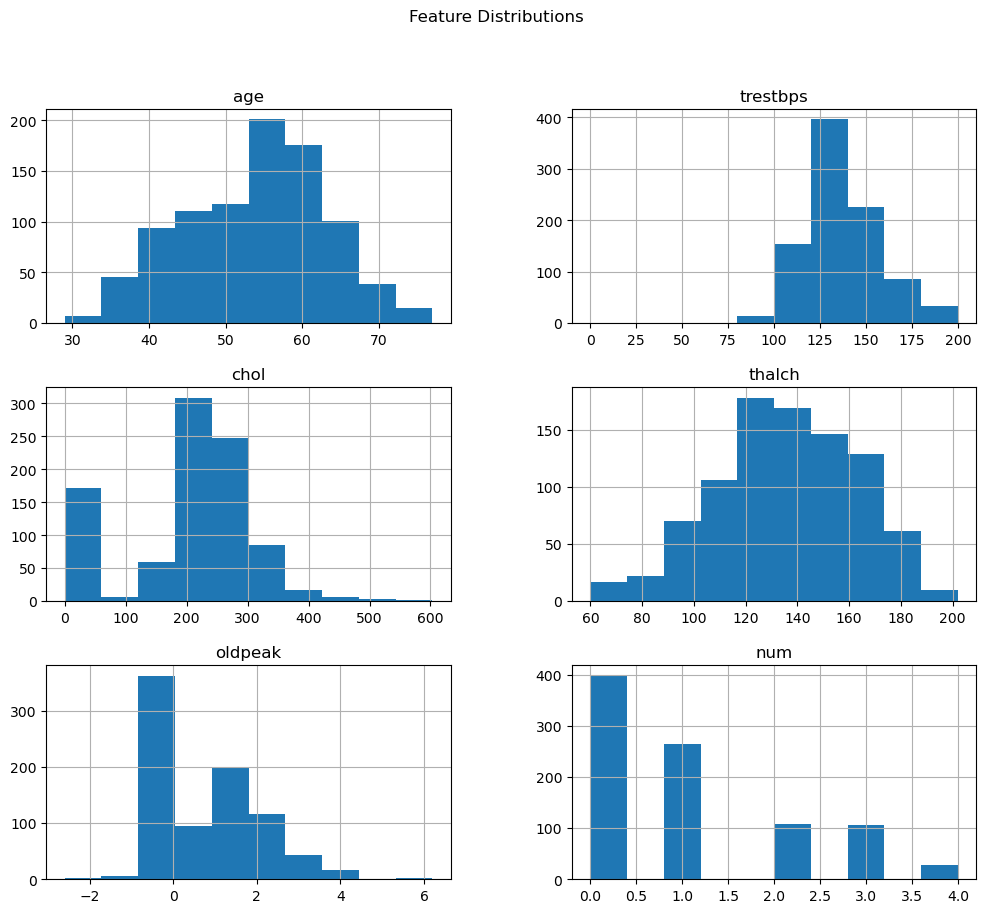

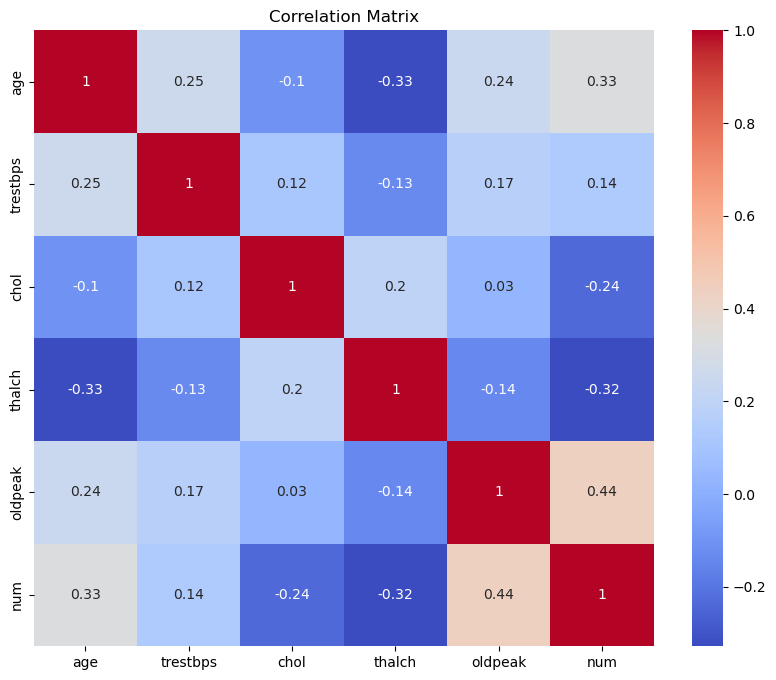

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = r"C:\Users\Rakshitha\Downloads\heart_disease.csv"
df = pd.read_csv(file_path)

# -------------------------------
# 1. Understand Structure
# -------------------------------
print("Shape of dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
print(df.head())

# -------------------------------
# 2. Missing Values
# -------------------------------
print("\nMissing Values:")
print(df.isnull().sum())

# -------------------------------
# 3. Check Duplicates (Inconsistency)
# -------------------------------
print("\nDuplicate Rows:", df.duplicated().sum())

# -------------------------------
# 4. Statistical Summary
# -------------------------------
print("\nStatistical Summary:")
print(df.describe())

# -------------------------------
# 5. Outlier Detection (Boxplot)
# -------------------------------
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
numeric_df.boxplot()
plt.xticks(rotation=90)
plt.title("Box Plot for Outlier Detection")
plt.show()

# -------------------------------
# 6. Distribution (Histograms)
# -------------------------------
numeric_df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

# -------------------------------
# 7. Correlation Matrix (Fixed Error)
# -------------------------------
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

##### 3. Feature Engineering:
    
If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.


In [4]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset
file_path = r"C:\Users\Rakshitha\Downloads\heart_disease.csv"
df = pd.read_csv(file_path)

# -------------------------------
# 1. Handle Missing Values
# -------------------------------
# For numerical columns → fill with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# For categorical columns → fill with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# -------------------------------
# 2. Encode Categorical Variables
# -------------------------------
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# -------------------------------
# 3. Feature Scaling
# -------------------------------
scaler = StandardScaler()

# Scale only numerical columns
df[num_cols] = scaler.fit_transform(df[num_cols])

# -------------------------------
# 4. Final Check
# -------------------------------
print("Processed Data (First 5 Rows):")
print(df.head())

print("\nData Types After Processing:")
print(df.dtypes)

print("\nAny Missing Values Left?")
print(df.isnull().sum())

Processed Data (First 5 Rows):
        age  sex  cp  trestbps      chol  fbs  restecg    thalch  exang  \
0  1.053038    1   3  0.610437  0.275348    1        0  0.542393      0   
1 -1.468059    1   1  0.096682 -0.005005    0        1 -0.162173      0   
2  0.365466    1   0  0.353560 -0.107801    0        1  0.464108      0   
3 -0.207510    1   3 -0.776700 -0.163871    0        0  2.108096      0   
4  0.365466    1   0 -1.187703 -0.023695    0        1 -0.397029      1   

    oldpeak  slope  thal       num  
0  1.445746      0     0 -0.924379  
1 -0.818356      1     0 -0.924379  
2 -0.424599      1     0 -0.924379  
3 -0.818356      1     0 -0.924379  
4  0.658232      1     0 -0.924379  

Data Types After Processing:
age         float64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalch      float64
exang         int64
oldpeak     float64
slope         int64
thal          int64
num         float64
dtype:

C:\Users\Rakshitha\AppData\Local\Temp\ipykernel_16492\3344763752.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\Rakshitha\AppData\Local\Temp\ipykernel_16492\3344763752.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].fillna(df[col].mode(

##### 4. Decision Tree Classification:
    
Split the dataset into training and testing sets (e.g., using an 80-20 split).
    
Implement a Decision Tree Classification model using a library like scikit-learn.
    
Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).


In [6]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Load dataset
file_path = r"C:\Users\Rakshitha\Downloads\heart_disease.csv"
df = pd.read_csv(file_path)

# -------------------------------
# 1. Preprocessing
# -------------------------------
# Convert categorical variables to numeric
df = pd.get_dummies(df, drop_first=True)

# Handle missing values
df = df.fillna(df.median(numeric_only=True))

# -------------------------------
# 2. Split Features & Target
# -------------------------------
# Automatically select last column as target
target = df.columns[-1]

print("Target Column:", target)

X = df.drop(target, axis=1)
y = df[target]

# -------------------------------
# 3. Train-Test Split (80-20)
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 4. Train Decision Tree Model
# -------------------------------
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# 5. Predictions
# -------------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# -------------------------------
# 6. Evaluation Metrics
# -------------------------------
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Target Column: thal_reversable defect

Accuracy: 0.755
Precision: 0.7246376811594203
Recall: 0.625
F1 Score: 0.6711409395973155
ROC-AUC Score: 0.7333333333333333

Classification Report:
              precision    recall  f1-score   support

       False       0.77      0.84      0.80       120
        True       0.72      0.62      0.67        80

    accuracy                           0.76       200
   macro avg       0.75      0.73      0.74       200
weighted avg       0.75      0.76      0.75       200



##### 5. Hyperparameter Tuning:
    
Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.


In [7]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load dataset
file_path = r"C:\Users\Rakshitha\Downloads\heart_disease.csv"
df = pd.read_csv(file_path)

# -------------------------------
# 1. Preprocessing
# -------------------------------
df = pd.get_dummies(df, drop_first=True)
df = df.fillna(df.median(numeric_only=True))

# -------------------------------
# 2. Split Features & Target
# -------------------------------
target = df.columns[-1]

X = df.drop(target, axis=1)
y = df[target]

# -------------------------------
# 3. Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 4. Hyperparameter Grid
# -------------------------------
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10]
}

# -------------------------------
# 5. GridSearchCV
# -------------------------------
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# -------------------------------
# 6. Best Parameters
# -------------------------------
print("Best Parameters:", grid.best_params_)

# -------------------------------
# 7. Evaluate Best Model
# -------------------------------
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best Parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 2}

Accuracy: 0.78

Classification Report:
               precision    recall  f1-score   support

       False       0.81      0.83      0.82       120
        True       0.74      0.70      0.72        80

    accuracy                           0.78       200
   macro avg       0.77      0.77      0.77       200
weighted avg       0.78      0.78      0.78       200



##### 6. Model Evaluation and Analysis:
    
Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
Visualize the decision tree structure to understand the rules learned by the model and identify important features


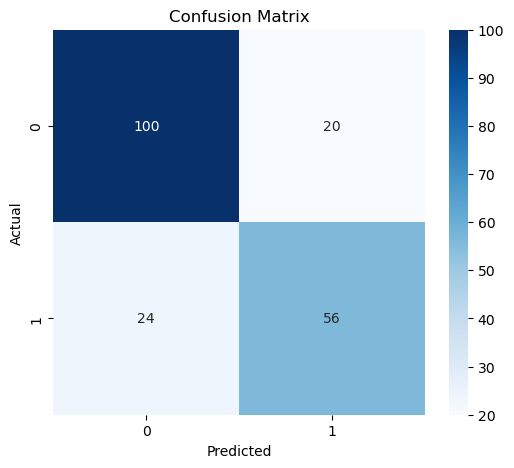

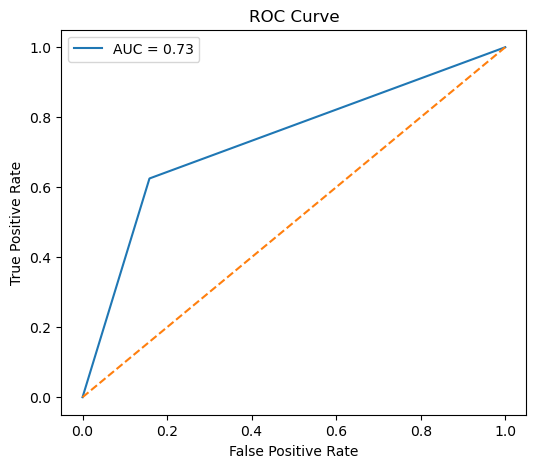

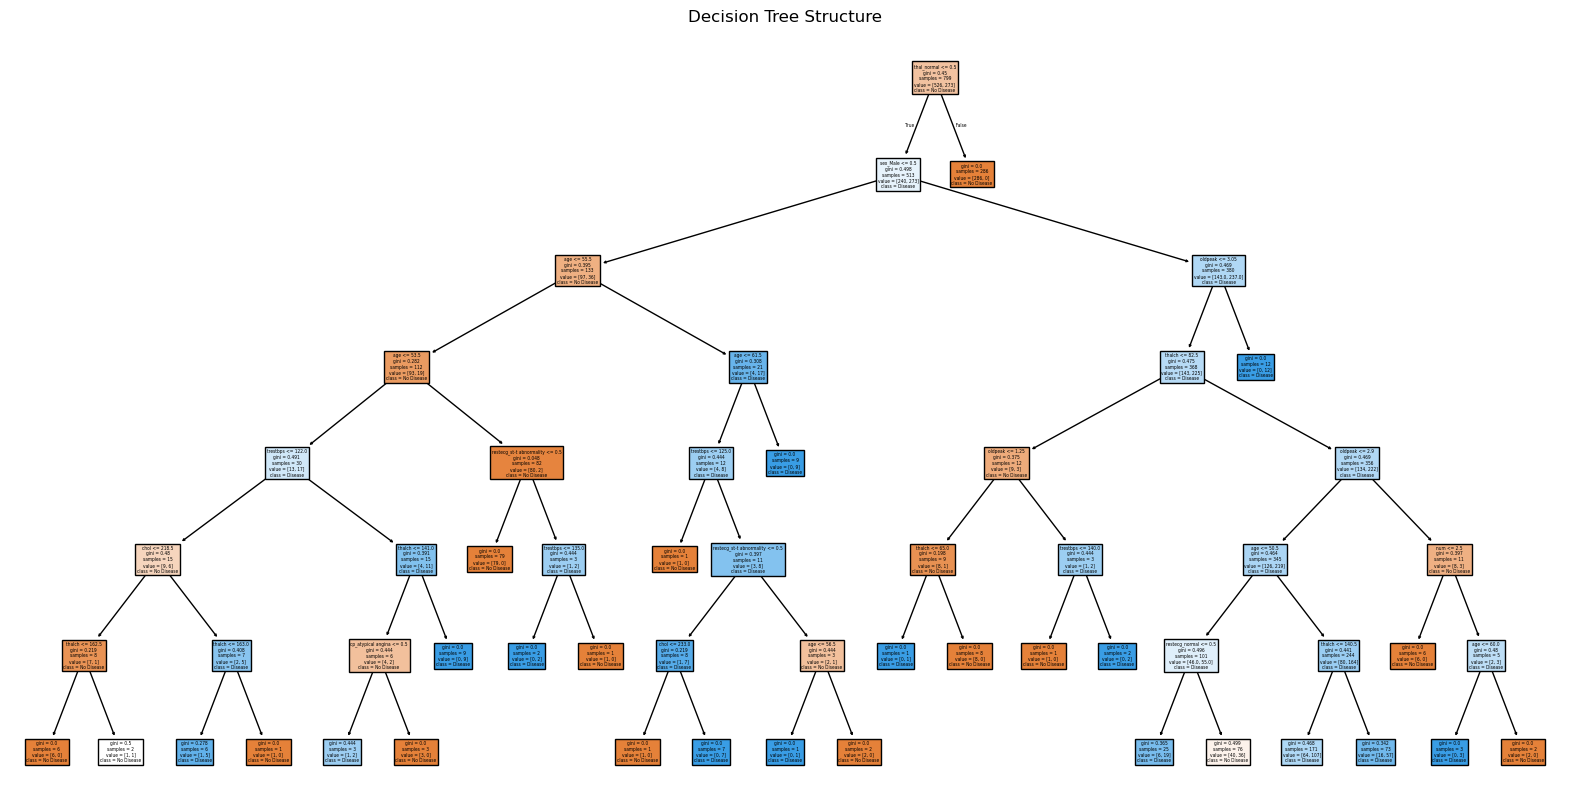


Top Features:
 thal_normal                 0.511462
age                         0.170154
sex_Male                    0.120746
thalch                      0.062060
oldpeak                     0.037832
trestbps                    0.026078
chol                        0.021357
restecg_st-t abnormality    0.018930
restecg_normal              0.015167
num                         0.009656
dtype: float64


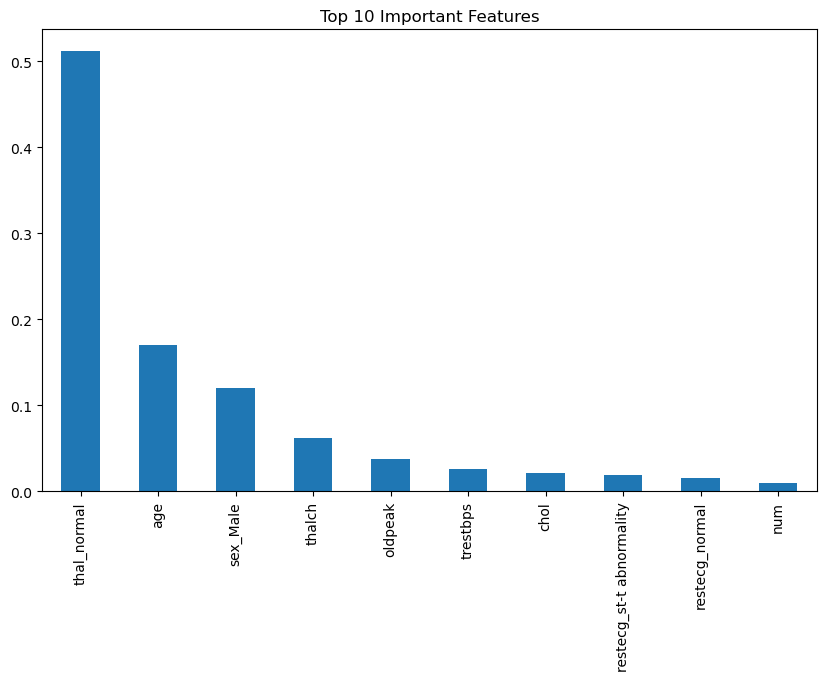

In [8]:
# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.tree import plot_tree

# -------------------------------
# 1. Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# -------------------------------
# 2. ROC Curve
# -------------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# -------------------------------
# 3. Decision Tree Visualization
# -------------------------------
plt.figure(figsize=(20,10))
plot_tree(best_model,
          feature_names=X.columns,
          class_names=['No Disease', 'Disease'],
          filled=True)
plt.title("Decision Tree Structure")
plt.show()

# -------------------------------
# 4. Feature Importance
# -------------------------------
import pandas as pd

feature_importance = pd.Series(best_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("\nTop Features:\n", feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

#### Interview Questions:

##### 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

##### Common Hyperparameters of Decision Tree & Their Effects

Decision Tree models have several hyperparameters that control how the tree is built and how well it performs.

🔹 1. max_depth

Meaning: Maximum depth (levels) of the tree

Effect:

Small depth → Underfitting (model too simple )

Large depth → Overfitting (model too complex )

 Controls model complexity

🔹 2. min_samples_split

Meaning: Minimum number of samples required to split a node

Effect:

Small value → more splits → overfitting

Large value → fewer splits → underfitting

 Prevents unnecessary splits

🔹 3. min_samples_leaf

Meaning: Minimum samples required in a leaf node

Effect:

Small value → very specific rules → overfitting

Large value → smoother model → better generalization

 Reduces noise in predictions

🔹 4. criterion

Meaning: Function to measure split quality

Types:

gini → Gini impurity

entropy → Information gain

Effect:

Both give similar results, but may slightly change accuracy

 Decides how best splits are chosen

🔹 5. max_features

Meaning: Number of features considered for splitting
    
Effect:
    
Smaller value → more randomness → reduces overfitting
    
Larger value → better fit but risk of overfitting
    
 Useful in controlling variance
     
🔹 6. max_leaf_nodes
    
Meaning: Maximum number of leaf nodes
    
Effect:
    
Limits tree size
    
Prevents over-complex trees
    
 Controls model size

##### 2. What is the difference between the Label encoding and One-hot encoding?

##### 1. Label Encoding

Meaning: Converts each category into a unique number

Example:

Male → 0

Female → 1

Characteristics:

Uses single column

Introduces order (ranking) between categories 

Problem:

Model may think 1 > 0 (which is not true for categories)

##### 2. One-Hot Encoding

Meaning: Converts categories into multiple binary columns

Example:

Gender_Male   Gender_Female
     1              0
     0              1
Characteristics:

Creates separate column for each category

No order or ranking 

Advantage:

More accurate for categorical data